In [1]:
suppressPackageStartupMessages({
    library(MouseGastrulationData)
    library(dplyr)
    library(data.table)
    library(scran)
    library(scater)
    library(batchelor)
    library(argparse)
})
set.seed(12345)

In [2]:
here::i_am("Get_data_plus_mapping.ipynb")

# Load mapping functions
source(here::here("mapping/run/mnn/mapping_functions_extended.R"))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Tal1/code



In [3]:
args = list()
args$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds'
args$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'
args$atlas_stages = c('E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5')
args$npcs = 40
args$n_neighbours = 15
args$cosine_normalisation = FALSE

In [4]:
sce = Tal1ChimeraData()

snapshotDate(): 2022-10-31

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for document

In [5]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

In [6]:
################
## Load query ##
################

# Get query data
sce_query = sce
meta_query = as.data.table(colData(sce_query))[,-c('stage.mapped', 'celltype.mapped')]
tmp <- meta_query %>% .[cell%in%colnames(sce_query)] %>% setkey(cell) %>% .[colnames(sce_query)]
stopifnot(tmp$cell == colnames(sce_query))
colData(sce_query) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_query),] %>% DataFrame()

In [7]:
sce

class: SingleCellExperiment 
dim: 29453 56122 
metadata(0):
assays(1): counts
rownames(29453): Xkr4 Gm1992 ... ENSMUSG00000095742 tomato-td
rowData names(2): ENSEMBL SYMBOL
colnames(56122): cell_1 cell_2 ... cell_56121 cell_56122
colData names(9): cell barcode ... pool sizeFactor
reducedDimNames(1): pca.corrected
mainExpName: NULL
altExpNames(0):

In [8]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)] 

# Filter
if (isTRUE(args$test)) meta_atlas <- head(meta_atlas,n=1000)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()

# Sanity cehcks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

In [9]:
sce_atlas

class: SingleCellExperiment 
dim: 18926 75012 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(18926): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000063897 ENSMUSG00000095742
rowData names(0):
colnames(75012): cell_361 cell_362 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [10]:
#####################
## Define gene set ##
#####################

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [11]:
sce_atlas[1:5, 1:5]

class: SingleCellExperiment 
dim: 5 5 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(5): Xkr4 Rp1 Sox17 Mrpl15 Lypla1
rowData names(0):
colnames(5): cell_361 cell_362 cell_363 cell_364 cell_365
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [12]:
head(gene_metadata)

chr,ens_id,symbol
<chr>,<chr>,<chr>
chr1,ENSMUSG00000051951,Xkr4
chr1,ENSMUSG00000025900,Rp1
chr1,ENSMUSG00000025902,Sox17
chr1,ENSMUSG00000033845,Mrpl15
chr1,ENSMUSG00000025903,Lypla1
chr1,ENSMUSG00000104217,Gm37988


In [13]:
# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]
#Other imprinted genes: 
#- Nnat (https://www.genecards.org/cgi-bin/carddisp.pl?gene=NNAT)
#- Grb10 (https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRB10)

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes.intersect,invert=T)] # filter out non-informative genes
genes.intersect <- genes.intersect[grep("^Hbb|^Hba",genes.intersect,invert=T)] # test removing Haem genes 
genes.intersect <- genes.intersect[!genes.intersect %in% c(imprint, 'Grb10', 'Nnat')] # remove imprinted genes
genes.intersect <- genes.intersect[!genes.intersect %in% c("Xist", "Tsix")] # remove Xist & Tsix
genes.intersect <- genes.intersect[!genes.intersect=="tomato-td"] # remove tomato itself
genes.intersect <- genes.intersect[!genes.intersect %in% gene_metadata[chr=="chrY",symbol]] # no genes on y-chr 

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [14]:
#######################
## Feature selection ##
#######################

# Load gene statistics from the atlas
gene_stats.dt <- fread(paste0(io$atlas.basedir,"/results/gene_statistics/gene_statistics.txt.gz")) %>%
.[gene%in%genes.intersect]
genes_to_use <- gene_stats.dt %>% setorder(-var_pseudobulk, na.last = T) %>% head(n=2500) %>% .$gene  

stopifnot(genes_to_use%in%rownames(sce_atlas))
stopifnot(genes_to_use%in%rownames(sce_query))

sce_query = sce_query[genes_to_use,]
sce_atlas = sce_atlas[genes_to_use,]

In [15]:
sce_query
sce_atlas

class: SingleCellExperiment 
dim: 2500 56122 
metadata(0):
assays(1): counts
rownames(2500): Tdgf1 Hoxaas3 ... Cd93 Bdh2
rowData names(2): ENSEMBL SYMBOL
colnames(56122): cell_1 cell_2 ... cell_56121 cell_56122
colData names(6): barcode sample ... pool sizeFactor
reducedDimNames(1): pca.corrected
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 2500 75012 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(2500): Tdgf1 Hoxaas3 ... Cd93 Bdh2
rowData names(0):
colnames(75012): cell_361 cell_362 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [16]:
mapping_full = mclapply(unique(meta_query$sample), function(x){
    mapping  <- mapWrap(
          sce_atlas = sce_atlas,
          meta_atlas = meta_atlas,
          sce_query = sce_query[,meta_query[sample==x, cell]],
          meta_query = meta_query[sample==x, ],
          genes = genes_to_use,
          npcs = args$npcs,
          k = args$n_neighbours,
          cosineNorm = args$cosine_normalisation,
          order = NULL
        )
    
    mapping.dt <- mapping$mapping %>% 
      .[,c("cell","celltype.mapped","celltype.score","celltype_extended.mapped","celltype_extended.score","stage.mapped", "cellstage.score", "closest.cell")] %>% 
      as.data.table
    
    return(mapping.dt)
}, mc.cores=1)

Normalizing joint dataset using cosineNorm=FALSE...

Done


2500 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Loading required package: BiocParallel

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done


Normalizing joint dataset using cosineNorm=FALSE...

Done


2500 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done


Normalizing joint dataset using cosineNorm=FALSE...

Done


2500 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done


Normalizing joint dataset using cosineNorm=FALSE...

Done


2500 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing ou

In [17]:
mapping_full = mapping_full %>% rbindlist()

In [18]:
head(mapping_full)

cell,celltype.mapped,celltype.score,celltype_extended.mapped,celltype_extended.score,stage.mapped,cellstage.score,closest.cell
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
cell_1,Forebrain_Midbrain_Hindbrain,1.0000000,Ventral_hindbrain_progenitors,0.8666667,E8.5,0.6666667,cell_40791
cell_2,Forebrain_Midbrain_Hindbrain,0.9333333,Optic_vesicle,0.6666667,E8.25,0.6000000,cell_69576
cell_3,Paraxial_mesoderm,1.0000000,Dermomyotome,0.4000000,E8.25,0.7333333,cell_67076
cell_4,ExE_mesoderm,0.8666667,Lateral_plate_mesoderm,0.8000000,E8.25,0.6000000,cell_68846
cell_5,Intermediate_mesoderm,0.7333333,Paraxial_mesoderm,0.8666667,E8.0,0.5333333,cell_123570
cell_6,Cardiomyocytes,0.8666667,Cardiomyocytes_SHF_1,0.6000000,E8.25,0.6000000,cell_71129


In [19]:
meta_full = merge(meta_query, mapping_full, by='cell') %>% 
    .[match(colnames(sce_query), cell)]

In [20]:
fwrite(mapping_full, '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Tal1/processed/metadata_mapped.txt.gz', sep="\t")

In [21]:
meta_full.df = as.data.frame(meta_full)
rownames(meta_full.df) = meta_full.df$cell

In [22]:
colData(sce_query) = meta_full.df %>% DataFrame()

In [23]:
saveRDS(sce_query, '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Tal1/processed/SingleCellExperiment.rds')

In [24]:
test = merge(meta_full, meta_atlas[,c('cell', 'umapX','umapY')], by.x='closest.cell', by.y='cell')

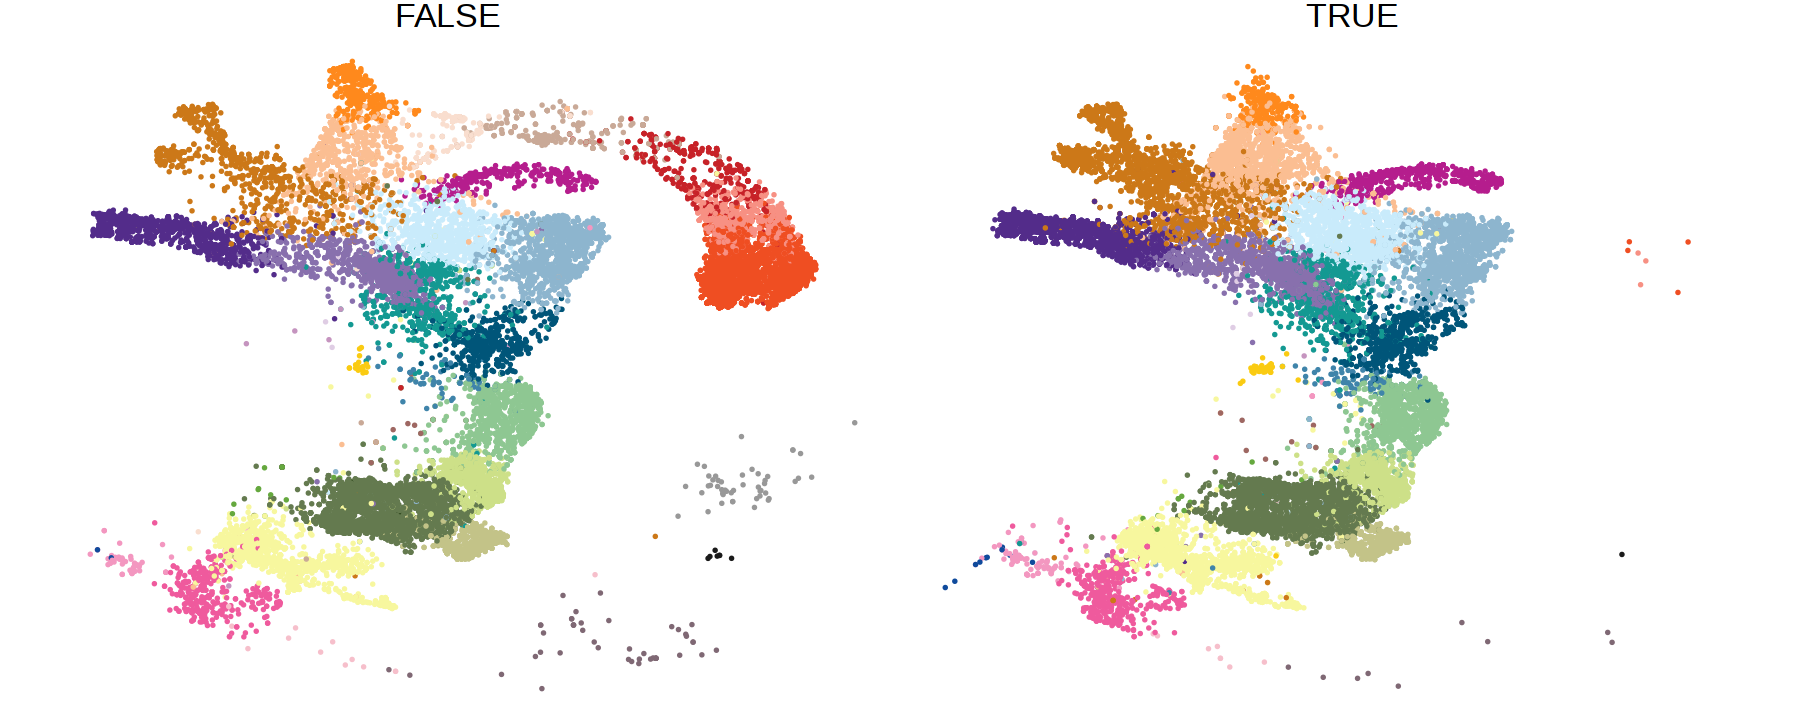

In [25]:
options(repr.plot.width=15, repr.plot.height=6)
ggplot(test, aes(umapX, umapY, color=celltype.mapped)) + 
    geom_point(size=0.5) + 
    scale_color_manual(values=opts$celltype.colors) + 
    facet_wrap(~tomato) + 
    theme_void() + 
    theme(legend.position='none',
          strip.background=element_blank(),
          strip.text=element_text(size=20))

In [45]:
sce = sce[,match(test$cell, colnames(sce))]

In [50]:
sce = logNormCounts(sce)

In [65]:
options(repr.plot.width=15, repr.plot.height=6)
gene_list = c('Lyve1', 'Stab2', 'Mrc1', 'Itga6', 'Itga2b')
gene_list = c('Dll4', 'Cd24a', 'Col26a1', 'Hoxa11','Klf14', 'Wfdc2')

plist = lapply(gene_list, function(x){
    test2 = test
    test2$gene = as.vector(logcounts(sce[x,]))
    test2 = test2[order(gene)]
    p = ggplot(test2, aes(umapX, umapY, color=gene)) + 
        geom_point(size=0.5) + 
        viridis::scale_color_viridis() +
        facet_wrap(~tomato) + 
        ggtitle(x) +
        theme_void() + 
        theme(legend.position='none',
              strip.background=element_blank(),
              strip.text=element_text(size=20),
              plot.title=element_text(size=30, hjust=0.5))
    return(p)
})

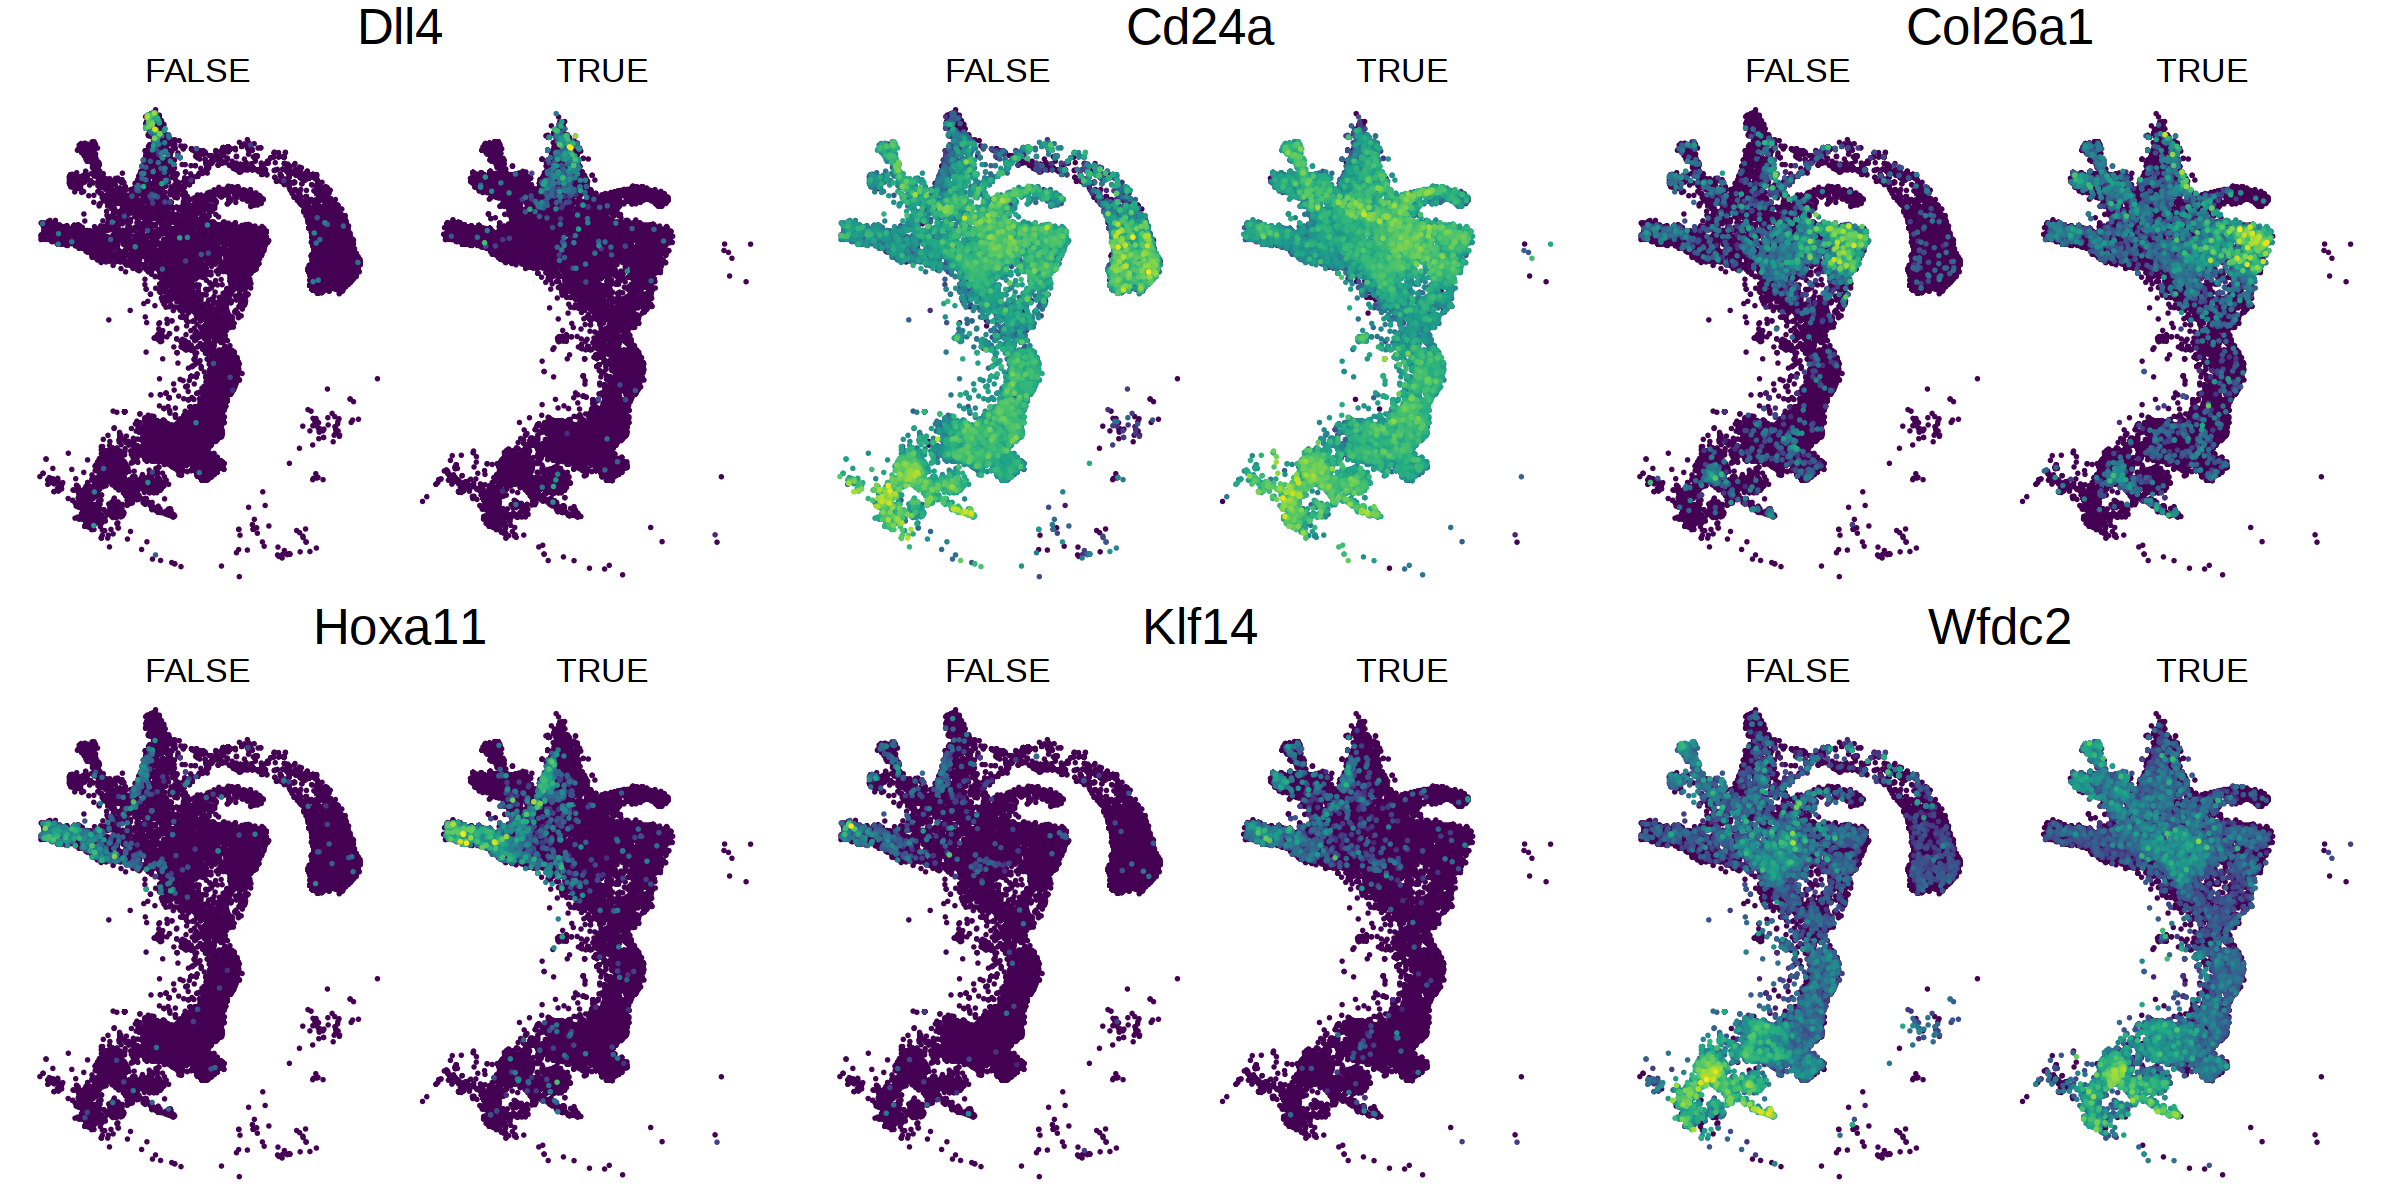

In [66]:
options(repr.plot.width=20, repr.plot.height=10)
cowplot::plot_grid(plotlist=plist, ncol=3)